## Sentiment Analysis of Tech Company Tweets

This notebook aims to classify tweets about technology companies (mobiles, computers, laptops, etc.) into 'Positive' or 'Negative' sentiment categories.  steps:

1.  **Environment Setup**: Install necessary libraries.
2.  **Data Handling**: Load and clean the dataset.
3.  **Model Training**: Implement and train a DistilBERT model for sequence classification.
4.  **Evaluation**: Assess model performance using Accuracy, Confusion Matrix, and Classification Report.
5.  **Inference**: Create a function to predict sentiment for new tweets.

In [8]:
# Install necessary libraries
!pip install pandas transformers scikit-learn torch
!pip install accelerate -U

## 1. Data Handling

First, we need to load our dataset. If you have a CSV file, you can replace the dummy data generation with your file loading code. The dataset should ideally have a 'text' column for the tweet content and a 'sentiment' column (e.g., 'Positive'/'Negative').

In [9]:
import pandas as pd

# --- Option 1: Create a dummy dataset (for demonstration) ---
data = {
    'text': [
        'The new iPhone is amazing! Best phone ever.',
        'My laptop crashed again. So frustrating!',
        'Loving the new update on my Samsung phone.',
        'Customer service for XYZ computers was terrible.',
        'This new tablet is perfect for my work.',
        'Never buying anything from that brand again.',
        'The battery life of this device is outstanding.',
        'Slow performance and constant bugs. Disappointed.',
        'Just got my new MacBook Pro and it \'s a beast!',
        'Worst tech purchase of the year. Complete waste of money.'
    ],
    'sentiment': [
        'Positive', 'Negative', 'Positive', 'Negative', 'Positive',
        'Negative', 'Positive', 'Negative', 'Positive', 'Negative'
    ]
}
df = pd.DataFrame(data)

# --- Option 2: Load your own dataset (uncomment and modify if you have a CSV) ---
# try:
#     df = pd.read_csv('your_tweets_dataset.csv')
#     # Rename columns if they are different from 'text' and 'sentiment'
#     # df = df.rename(columns={'your_tweet_column': 'text', 'your_sentiment_column': 'sentiment'})
# except FileNotFoundError:
#     print("Please upload 'your_tweets_dataset.csv' or adjust the file path.")
#     # Fallback to dummy data if file not found, or raise an error
#     df = pd.DataFrame(data) # Using dummy data as fallback

display(df.head())
display(df['sentiment'].value_counts())


,text,sentiment
0,The new iPhone is amazing! Best phone ever.,Positive
1,My laptop crashed again. So frustrating!,Negative
2,Loving the new update on my Samsung phone.,Positive
3,Customer service for XYZ computers was terrible.,Negative
4,This new tablet is perfect for my work.,Positive


,count
sentiment,
Positive,5
Negative,5


### Data Cleaning

We need to clean the tweet text by removing URLs, @mentions, and special characters to ensure better model performance.

In [10]:
import re

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove special characters and numbers (keeping only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
display(df[['text', 'cleaned_text']].head())

,text,cleaned_text
0,The new iPhone is amazing! Best phone ever.,the new iphone is amazing best phone ever
1,My laptop crashed again. So frustrating!,my laptop crashed again so frustrating
2,Loving the new update on my Samsung phone.,loving the new update on my samsung phone
3,Customer service for XYZ computers was terrible.,customer service for xyz computers was terrible
4,This new tablet is perfect for my work.,this new tablet is perfect for my work


## 2. Modeling with Transformers

We will use a DistilBERT model from the `transformers` library for sequence classification. This involves tokenizing the text and preparing the dataset for training.

In [11]:
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset

# Map sentiment labels to integers
sentiment_map = {'Negative': 0, 'Positive': 1}
df['labels'] = df['sentiment'].map(sentiment_map)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['labels'], test_size=0.2, random_state=42, stratify=df['labels'])

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize the data
train_encodings = tokenizer(list(X_train), truncation=True, padding=True)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True)

# Create a PyTorch Dataset
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TweetDataset(train_encodings, y_train.values)
test_dataset = TweetDataset(test_encodings, y_test.values)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 8
Test set size: 2


### Model Training

Now we will load the pre-trained DistilBERT model and fine-tune it on our tweet sentiment dataset.

In [12]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load pre-trained DistilBERT model for sequence classification
# num_labels is 2 for 'Positive' and 'Negative'
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=8,   # batch size per device during training
    per_device_eval_batch_size=8,    # batch size per device during evaluation
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=1,                 # Log every step for very small dataset
    # Removed evaluation_strategy and save_strategy to bypass TypeError
)

# Define metrics computation function
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', zero_division=0)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Create Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but n

Step,Training Loss
1,0.698291
2,0.642289
3,0.618360


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3, training_loss=0.6529801686604818, metrics={'train_runtime': 22.1298, 'train_samples_per_second': 1.085, 'train_steps_per_second': 0.136, 'total_flos': 74512911744.0, 'train_loss': 0.6529801686604818, 'epoch': 3.0})

## 3. Evaluation

After training, we will evaluate the model's performance on the test set using accuracy, a confusion matrix, and a classification report.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.5000


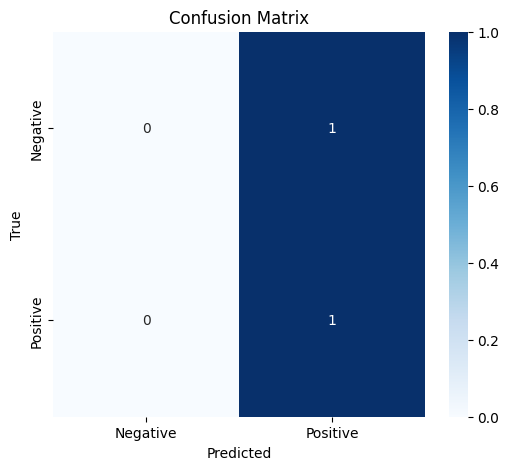


Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions from the trainer
predictions_output = trainer.predict(test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

# Calculate overall accuracy
accuracy = accuracy_score(labels, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate Classification Report
report = classification_report(labels, predictions, target_names=['Negative', 'Positive'])
print("\nClassification Report:")
print(report)

## 4. Inference

Finally, let's create a function to predict the sentiment of a custom tweet using our trained model.

In [14]:
def predict_sentiment(tweet_text):
    # Clean the input tweet
    cleaned_tweet = clean_text(tweet_text)

    # Tokenize the cleaned tweet
    inputs = tokenizer(cleaned_tweet, return_tensors='pt', truncation=True, padding=True)

    # Move inputs to the same device as the model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Make prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted class (0 for Negative, 1 for Positive)
    logits = outputs.logits
    predicted_class_id = torch.argmax(logits, dim=-1).item()

    # Map back to sentiment label
    reverse_sentiment_map = {0: 'Negative', 1: 'Positive'}
    predicted_sentiment = reverse_sentiment_map[predicted_class_id]

    return predicted_sentiment

# Test the inference function
tweet1 = 'The new laptop battery life is amazing!'
tweet2 = 'My smart home device is constantly disconnecting, very annoying.'
tweet3 = 'Just bought the latest smartphone, it\'s super fast!'
tweet4 = 'This software update broke everything. Horrible experience.'

print(f"Tweet: '{tweet1}' -> Sentiment: {predict_sentiment(tweet1)}")
print(f"Tweet: '{tweet2}' -> Sentiment: {predict_sentiment(tweet2)}")
print(f"Tweet: '{tweet3}' -> Sentiment: {predict_sentiment(tweet3)}")
print(f"Tweet: '{tweet4}' -> Sentiment: {predict_sentiment(tweet4)}")

Tweet: 'The new laptop battery life is amazing!' -> Sentiment: Positive
Tweet: 'My smart home device is constantly disconnecting, very annoying.' -> Sentiment: Positive
Tweet: 'Just bought the latest smartphone, it's super fast!' -> Sentiment: Positive
Tweet: 'This software update broke everything. Horrible experience.' -> Sentiment: Positive
